<a href="https://colab.research.google.com/github/marcos-mansur/load-forecast/blob/main/Notebook_7_LSTM_base_em_dias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pendulum

     |████████████████████████████████| 155 kB 4.1 MB/s 
     |████████████████████████████████| 489 kB 43.6 MB/s 


In [2]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import timeseries_dataset_from_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pendulum

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False


# Load Files

In [3]:
df_20XX = pd.read_csv(f'https://ons-dl-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_2009.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])

for x in range(2010,2021):
  df_20XX = pd.concat(objs = (df_20XX,pd.read_csv(f'https://ons-dl-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{x}.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])))

load_col = 'val_cargaenergiamwmed'
time_col = 'din_instante'

# Treat data

In [4]:
def get_friday(date_time): 
  """ get next friday = start the operative week"""
  
  # today
  dt = pendulum.datetime(date_time.year,date_time.month, date_time.day)
  # return next friday
  return  dt.next(pendulum.FRIDAY).strftime('%Y-%m-%d')


def treat_data(df,regiao='SUDESTE',operative_week_start=2):
  
  # round the values of load
  df['val_cargaenergiamwmed'] = np.round(df['val_cargaenergiamwmed'],2)
  # drop last 4 rows that doesn't have load values
  df.dropna(axis=0, how='any',inplace=True)
  # filter data by subsystem 
  try:
    df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
  except:
    pass
  # dropa colunas sobre região
  df.drop(labels=['nom_subsistema','id_subsistema'], inplace=True, axis=1,errors='ignore')


  # get next friday - begins the operative week
  next_fri = get_friday(df['din_instante'].iloc[0])
  # df starts with the begin of operative week
  df = df[df['din_instante'] >= next_fri].copy()

  # create column with week number 
  df.reset_index(inplace=True,drop=True)
  df['semana'] = (df.index)//7 
  
  return df

df = treat_data(df_20XX, regiao='SUDESTE')
df.head(3)

,din_instante,val_cargaenergiamwmed,semana
0,2009-01-02,26104.57,0
1,2009-01-03,25754.14,0
2,2009-01-04,23795.99,0


In [5]:
# save load values in a list
load_values = df[load_col].copy()
# tira a coluna de data do df e coloca na variável date_time
date_time = pd.to_datetime(df[time_col].copy())

timestamp_s = date_time.map(pd.Timestamp.timestamp)

date_time

0      2009-01-02
1      2009-01-03
2      2009-01-04
3      2009-01-05
4      2009-01-06
          ...    
4367   2020-12-27
4368   2020-12-28
4369   2020-12-29
4370   2020-12-30
4371   2020-12-31
Name: din_instante, Length: 4372, dtype: datetime64[ns]

# Visualize data

In [6]:
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['axes.grid'] = False

<function matplotlib.pyplot.show>

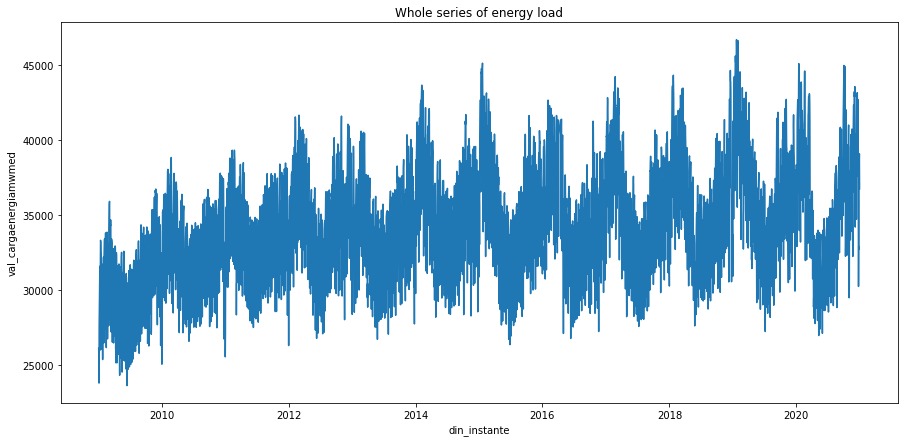

In [7]:
fig, ax = plt.subplots(figsize=(15,7))
sns.lineplot(x=date_time,y=load_values,ax=ax)
ax.set_title('Whole series of energy load')
plt.show

<function matplotlib.pyplot.show>

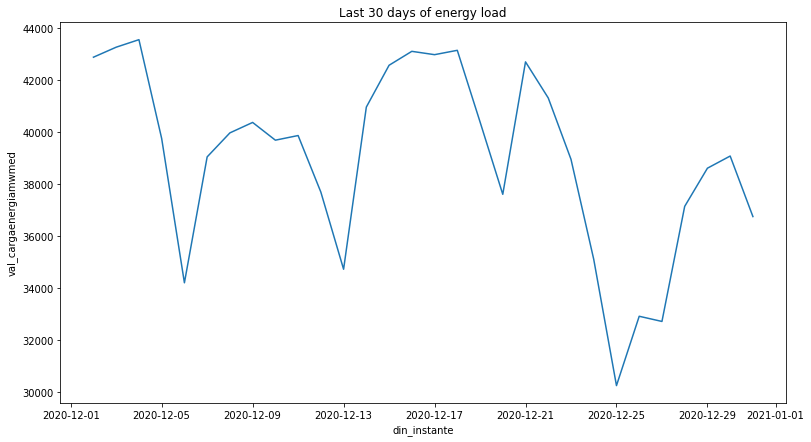

In [8]:
fig, ax = plt.subplots(figsize=(13,7))
sns.lineplot(x=date_time[-30:],y=load_values[-30:],ax=ax)
ax.set_title('Last 30 days of energy load')
plt.show

# Initialize constants

In [55]:
batch_size = 32
# target days to sum into weeks
target_period = 7 
# window size for each sample
window_size = 7*20
shuffle_buffer = 20
np.random.seed(42)
tf.random.set_seed(42)

print('window_size = ',window_size)

window_size =  140


# Split train test

In [49]:
def split_time(df):
  n = len(df)
  # end of training dataset, start of validation dataset
  split_val = int(n*0.7)
  # end of validation dataset, start of test dataset
  split_test = int(n*0.9)

  # split datasets
  train_df = df[0:split_val]
  val_df = df[split_val:split_test]
  test_df = df[split_test:]
  
  return train_df, val_df, test_df

train_df, val_df, test_df = split_time(df)

n = len(df)
# end of training dataset, start of validation dataset
split_val = int(n*0.7)
# end of validation dataset, start of test dataset
split_test = int(n*0.9)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pyplot.py'>

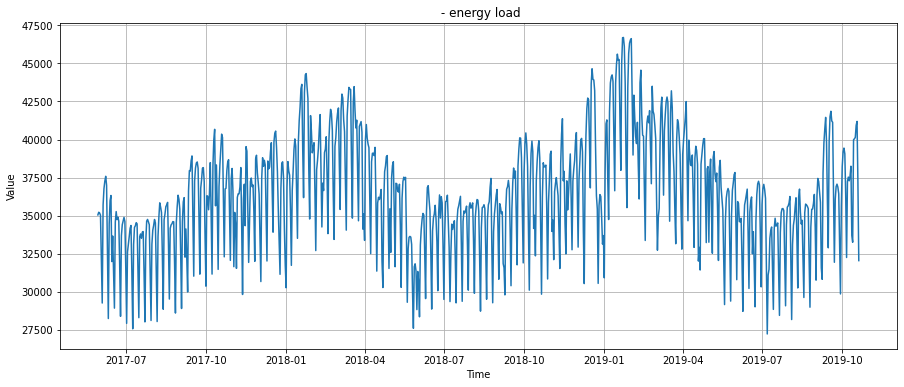

In [50]:
def plot_serie(df1, col = load_col ,start=0,end=None, title=''):
  plt.rcParams['figure.figsize'] = [15,6]
  plt.plot(df1[time_col][start:end],
           df1[col][start:end],)
  plt.title(title + ' - energy load')
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)
  return plt


plot_serie(val_df)

In [51]:
mean_load_week = df.groupby(by=['semana'])['val_cargaenergiamwmed'].mean()  
date_week = df.groupby(by=['semana'])['din_instante'].min()
df_target = pd.DataFrame(data=mean_load_week)
# data de inicio da semana prevista
df_target['data'] = date_week

# TensorFlow Dataset

In [52]:
def windowed_dataset(df, batch_size = batch_size, 
                     window_size = window_size, shuffle_buffer = shuffle_buffer, 
                     target_period = target_period):
  df = df.copy()
  # get next friday - begins the operative week
  next_fri = get_friday(df['din_instante'].iloc[0])
  # df starts with the begin of operative week
  df = df[df['din_instante'] >= next_fri]
  # CONSERTAR
  data_week = df[window_size:].groupby(by=['semana'])['din_instante'].min()


  series = df[load_col]
  # tf.dataset
  dataset = tf.data.Dataset.from_tensor_slices(series)
  # create windows 
  dataset = dataset.window(window_size + target_period, shift=7, drop_remainder=True)
  # make sure avery window is the same size / clip NaN at the end
  dataset = dataset.flat_map(lambda window: window.batch(window_size + target_period))
  # randomly shuffles the windows instances in the dataset 
  dataset = dataset.shuffle(shuffle_buffer)
  # separates features and target and average the target days
  dataset = dataset.map(lambda window: (window[:-target_period], 
                                        tf.math.reduce_sum(window[-target_period:]/target_period)))
  # batch
  dataset = dataset.batch(batch_size).prefetch(1)
  return dataset, data_week

train_dataset, train_data_week = windowed_dataset(df = train_df)
val_dataset, val_data_week = windowed_dataset(df = val_df)
test_dataset, teste_data_week = windowed_dataset(df = test_df)

In [15]:
len(val_data_week)

115

In [ ]:
for window in train_dataset:
  print([item.numpy() for item in window])
  break

# Train model


In [53]:
# Simple RNN
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(124, return_sequences=True, kernel_initializer='normal'),
    tf.keras.layers.LSTM(32, return_sequences=False, kernel_initializer='normal'),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


In [60]:
def compile_and_fit(model, data, val_data, epochs,
                    patience=4, filepath = 'RNN.hdf5'):
  # early stopping callback
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')
  # checkpoint callback
  checkpoint = ModelCheckpoint(filepath = filepath, monitor = 'loss', 
                               verbose = 1, save_best_only = True, mode = 'min')
  
  # compile
  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError()])
  # fit data
  history = model.fit(data, epochs=epochs,
                      validation_data= val_data,
                      callbacks=[early_stopping, checkpoint]) 
  return history

history = compile_and_fit(model, epochs = 20, 
                          data=train_dataset, 
                          val_data = val_dataset)

#print(os.listdir())

#print("Layer weights {}".format(l0.get_weights()))

Epoch 1/20
     13/Unknown - 5s 159ms/step - loss: 6138213.5000 - mean_absolute_error: 2007.5039
Epoch 1: loss improved from inf to 6138213.50000, saving model to RNN.hdf5
13/13 [==============================] - 6s 243ms/step - loss: 6138213.5000 - mean_absolute_error: 2007.5039 - val_loss: 11313545.0000 - val_mean_absolute_error: 3000.7007
Epoch 2/20
13/13 [==============================] - ETA: 0s - loss: 10354010.0000 - mean_absolute_error: 2573.7615
Epoch 2: loss did not improve from 6138213.50000
13/13 [==============================] - 2s 171ms/step - loss: 10354010.0000 - mean_absolute_error: 2573.7615 - val_loss: 5213800.5000 - val_mean_absolute_error: 1630.9464
Epoch 3/20
13/13 [==============================] - ETA: 0s - loss: 3595909.0000 - mean_absolute_error: 1449.9581
Epoch 3: loss improved from 6138213.50000 to 3595909.00000, saving model to RNN.hdf5
13/13 [==============================] - 2s 171ms/step - loss: 3595909.0000 - mean_absolute_error: 1449.9581 - val_loss: 

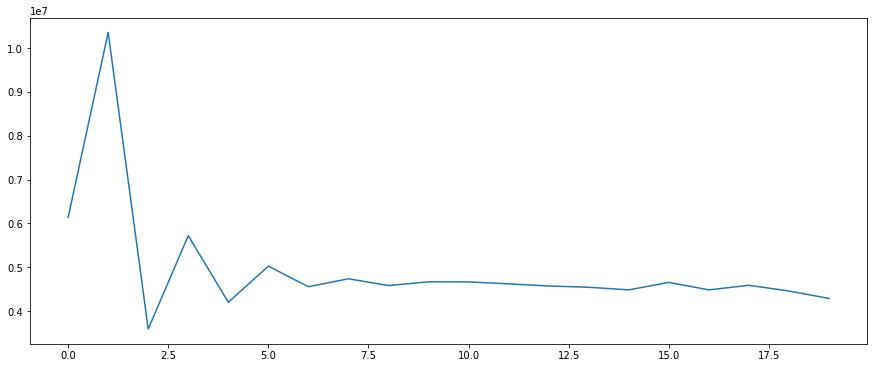

In [62]:
skip = 0
plt.plot(range(skip,len(history.history['loss'])),history.history['loss'][skip:])
#plt.plot(range(skip,len(history.history['mse'])),history.history['mse'][skip:])


# Prediction

In [68]:
val_performance = {}
val_performance['LSTM'] = model.evaluate(val_dataset)

performance = {}
performance['LSTM'] = model.evaluate(test_dataset)

2/2 [==============================] - 0s 60ms/step - loss: 3867411.7500 - mean_absolute_error: 1649.5919


In [64]:
forecast = []
forecast_date = []
for time in range(0,len(df) - window_size,7):
  forecast.append(model.predict(np.array(df[load_col][time:time + window_size])[np.newaxis]))
  forecast_date.append(df[time_col].iloc[time + window_size])

forecast = np.array(forecast)[:,0,0]

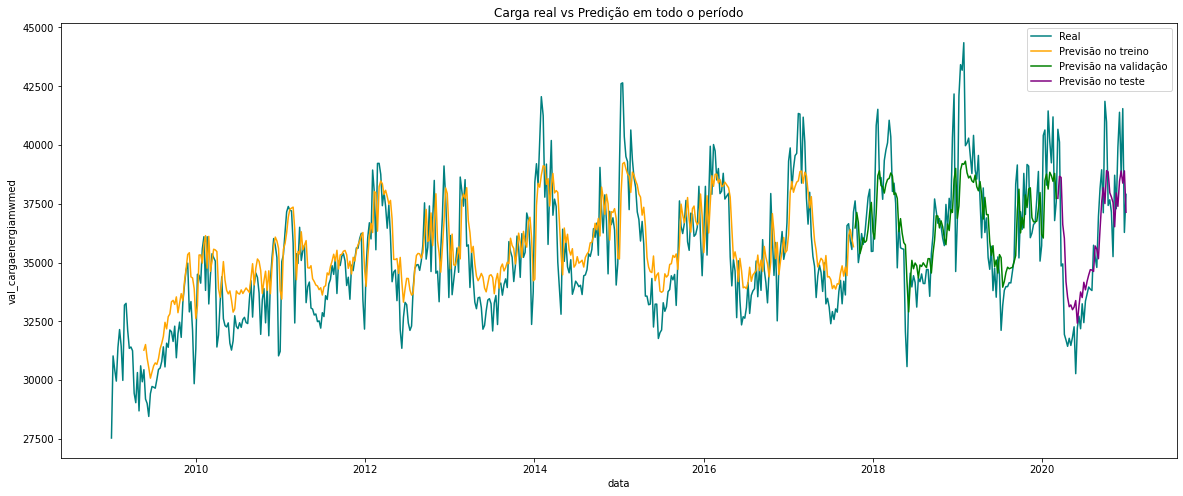

In [65]:
fix,ax=plt.subplots(figsize=(20, 8))

# plot measured data
sns.lineplot(x = df_target['data'], 
             y = df_target[load_col], ax=ax, color = 'teal')
# plot predicted training data
sns.lineplot(x = forecast_date[:int(split_val/7)],
             y = forecast[:int(split_val/7)], 
             ax=ax, color='orange')
# plot predicted validation data
sns.lineplot(x = forecast_date[int(split_val/7):int(split_test/7)],
             y = forecast[int(split_val/7):int(split_test/7)], 
             ax=ax, color='green')
# plot predicted test data
sns.lineplot(x = forecast_date[int(split_test/7):],
             y = forecast[int(split_test/7):], 
             ax=ax, color='purple')

#plt.plot(df.din_instante[split_val:],np.array(forecast)[split_val-window_size:,0,0])
plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação', 'Previsão no teste'])

In [ ]:
#print('MAE on train: ',
      tf.keras.metrics.mean_absolute_error(df_target[load_col].iloc[:int(split_val/7)],
                                           forecast[:int(split_val/7)]))

#print('MAE on validation: ',
      tf.keras.metrics.mean_absolute_error(
          df_target[load_col].iloc[int(split_val/7):int(split_test/7)],
          forecast[int(split_val/7):int(split_test/7)])
          )


"""CONSERTAR"""

# CONSERTAR A NORMALIZAÇÃO PRA MÉDIA MÓVEL